In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset

import mlflow
import mlflow.pytorch
from mlflow.tracking import MlflowClient
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight

from peft import LoraConfig, get_peft_model

# Fine Tunning

## RubertTiny1 

In [33]:
df = pd.read_csv("../data/rewiew_restorants_classical.csv")  

In [34]:
df = df[['text', 'setniment']]

In [35]:
model_name = "cointegrated/rubert-tiny"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['setniment'], test_size=0.3, random_state=42, stratify=df['setniment']
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

train_df = pd.DataFrame({"text": train_texts, "label": train_labels})
val_df   = pd.DataFrame({"text": val_texts, "label": val_labels})
test_df  = pd.DataFrame({"text": test_texts, "label": test_labels})

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(train_df).map(tokenize, batched=True)
val_dataset   = Dataset.from_pandas(val_df).map(tokenize, batched=True)
test_dataset  = Dataset.from_pandas(test_df).map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 15464/15464 [00:01<00:00, 8036.51 examples/s]


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_y = train_labels.to_numpy()
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_y
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [37]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


# Fine Tunning 

## 

In [38]:
num_labels = 2
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29564, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-1

/tmp/ipykernel_59123/4232072269.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.244700,0.298451,0.947232,0.837355,0.805675,0.821209
2,0.355400,0.294809,0.948267,0.822758,0.836199,0.829424
3,0.225700,0.296009,0.948461,0.815258,0.849957,0.832246


2026/01/02 06:33:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'RuBERT_Tiny_Reviews_Model' already exists. Creating a new version of this model...
Created version '3' of model 'RuBERT_Tiny_Reviews_Model'.


test_precision: 0.8041958041958042, test_recall: 0.8404987102321582, test_f1: 0.8219466050031532, roc_auc: 0.9766318995903922


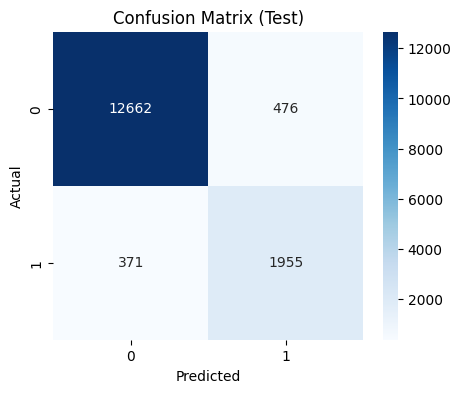

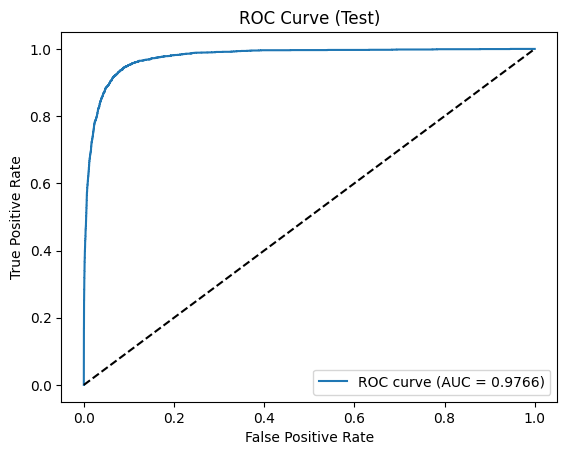

In [39]:
mlflow.set_experiment('ClassicalNLPSentiment')
registered_model_name = "RuBERT_Tiny_Reviews_Model"

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy ="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    precision = precision_score(labels, preds, pos_label=1)
    recall = recall_score(labels, preds, pos_label=1)
    f1 = f1_score(labels, preds, pos_label=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

data_collator = DataCollatorWithPadding(tokenizer)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)


with mlflow.start_run(run_name="RuBERT_Tiny_finetune"):

  
    trainer.train()


    mlflow.pytorch.log_model(
        pytorch_model=model,
        artifact_path="rubert_tiny_model",
        registered_model_name=registered_model_name
    )

   
    eval_metrics = trainer.evaluate(val_dataset)
    for key, value in eval_metrics.items():
        mlflow.log_metric(key, value)


    dataset_path = "../data/rewiew_restorants_classical.csv"
    df.to_csv(dataset_path, index=False)
    mlflow.log_artifact(dataset_path, artifact_path="dataset")

   
    client = MlflowClient()
    run_id = mlflow.active_run().info.run_id
    client.set_tag(run_id, "dataset_name", "geo_reviews_dataset.csv")


    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    all_logits = []
    all_labels = []

    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=32):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"]
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
        all_logits.append(logits.cpu())
        all_labels.append(labels)

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    preds = all_logits.argmax(dim=1).numpy()
    probs = F.softmax(all_logits, dim=1)[:,1].numpy() 
    
    y_true = all_labels.numpy()

        
    test_precision = precision_score(y_true, preds, pos_label=1)
    test_recall = recall_score(y_true, preds, pos_label=1)
    test_f1 = f1_score(y_true, preds, pos_label=1)
    test_roc_auc = roc_auc_score(y_true, probs) 

    mlflow.log_metrics({
        "precision_negative": test_precision,
        "recall_negative": test_recall,
        "f1_negative": test_f1,
        "roc_auc": test_roc_auc
    })

    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix (Test)")
    cm_path = "../artifacts/images/confusion_matrix_test.png"
    plt.savefig(cm_path)
    mlflow.log_artifact(cm_path)
    

    fpr, tpr, thresholds = roc_curve(all_labels, probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {test_roc_auc:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test)")
    plt.legend(loc="lower right")
    roc_path = "../artifacts/images/roc_curve_test.png"
    plt.savefig(roc_path)
    mlflow.log_artifact(roc_path)
print(f'test_precision: {test_precision}, test_recall: {test_recall}, test_f1: {test_f1}, roc_auc: {test_roc_auc}')

# Lora

In [ ]:
# базовая модель
model = AutoModelForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny",
    num_labels=2
)

# LoRA конфигурация
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

# применяем LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
